## Clone GitHub Repository

We will clone the `Welltory/hrv-covid19` repository to access the data.

In [25]:
!git clone https://github.com/Welltory/hrv-covid19.git

fatal: destination path 'hrv-covid19' already exists and is not an empty directory.


## Before we begin

Lets look at the background collection and use context

### Consent Information:

*   **Purpose:** The data collected is for research into the physiological effects of COVID-19 and the development of new methods for early detection and prevention of complications.
*   **Anonymity:** All data is anonymized before being shared with researchers. Individual identification is not possible.
*   **Data Use:** Data will be used for scientific research, possibly published in scientific articles, and may be used for product development.
*   **No Medical Advice:** Participation does not provide medical advice or diagnosis. The study is for research purposes only.

### License Information (MIT License):

*   **Permissions:** You are permitted to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the software.
*   **Conditions:** The above copyright notice and this permission notice shall be included in all copies or substantial portions of the software.
*   **Disclaimer:** The software is provided "as is", without warranty of any kind. The authors or copyright holders are not liable for any claim, damages, or other liability arising from the software or its use.

## Data Context and Sampling

### Data Context
This dataset is part of an open COVID-19 research project carried out in 2020 by the Welltory team. The primary goal was to detect patterns regarding the COVID-19 disease, its progression, and recovery. Users with positive COVID-19 status tracked their symptoms, heart rate variability, and other physiological data using the Welltory app and other wearables.

### Data Collection
Data was collected from users who consented to participate in the research. Participants used the Welltory app and other wearables to track various health metrics. The collected data includes physiological data (e.g., heart rate, HRV), sleep patterns, survey responses regarding symptoms and health status, and demographic information.

### Consent to Participate

### Data Types
The dataset consists of several CSV files, each containing specific types of information:

**data/participants.csv:** Contains general information about users (participants), including `user_code`, `gender`, `age_range`, `city`, `country`, `height`, `weight`, and `symptoms_onset`.

**data/sleep.csv:** Contains daily sleep measurements, including `user_code`, `day`, `sleep_begin`, `sleep_end`, `sleep_duration`, and various other sleep metrics like `sleep_awake_duration`, `sleep_rem_duration`, `sleep_light_duration`, `sleep_deep_duration`, and pulse data during sleep.

**data/surveys.csv:** Contains user responses to various surveys, identified by `user_code`, `scale`, `created_at`, `value`, and `text` descriptions of the value.

**data/scales_description.csv:** Provides descriptions and meanings for the values associated with different survey scales.

Other files not directly used in this analysis but available in the dataset include `heart_rate.csv`, `hrv_measurements.csv`, `blood_pressure.csv`, `weather.csv`, and `wearables.csv`.

### Data Sampling
The data was collected from Welltory app users who opted to participate in the research study. This suggests a convenience sampling method, where participants are individuals readily available and willing to join the study. Specific details on the total population size or selection criteria beyond voluntary participation are not explicitly provided in the available documentation.


## Initial Data Exploration - Listing Data Files

Let's first see what data files are available in the `hrv-covid19/data/` directory.

In [26]:
import os

data_path = '/content/hrv-covid19/data/'
csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]

print("Available CSV files in the data directory:")
for file_name in csv_files:
    print(f"- {file_name}")

Available CSV files in the data directory:
- scales_description.csv
- heart_rate.csv
- hrv_measurements.csv
- surveys.csv
- participants.csv
- blood_pressure.csv
- weather.csv
- wearables.csv
- sleep.csv


In [27]:
with open('/content/hrv-covid19/datatypes.md', 'r') as f:
    datatypes_content = f.read()
print(datatypes_content)

**Technical description of provided csv files**

**data/participants.csv**

Contains general information about users (participants)

|     |            |                            |           |
|-----|------------|----------------------------|-----------|
|     | **Column** | **Description**            | **Units** |
| 0   | user\_code | Unique user ID             |           |
| 1   | gender     | Gender: m/f/other or empty |           |
| 2   | age\_range | Age range                  |           |
| 3   | city       | City                       |           |
| 4   | country    | Country                    |           |
| 5   | height     | Height                     | cm        |
| 6   | weight     | Weight                     | kg        |
| 7   | symptoms_onset | The onset date of the symptoms of the disease. The format is MM/DD/YYYY. |    |

**data/hrv_measurements.csv**

Contains data based on heart rate variability (HRV) measurements collected from COVID-19 participants via the 

## Initial Data Exploration - Loading Selected Data Files

Now, let's load `sleep.csv`, `surveys.csv` `scales_description.csv`, and `participants.csv` into pandas DataFrames to begin our exploration.

In [28]:
import pandas as pd

# Load participants data
participants_df = pd.read_csv(os.path.join(data_path, 'participants.csv'))
print('Participants DataFrame:')
display(participants_df.head())

# Load sleep data
sleep_df = pd.read_csv(os.path.join(data_path, 'sleep.csv'))
print('\nSleep DataFrame:')
display(sleep_df.head())

# Load scales description data
scales_description_df = pd.read_csv(os.path.join(data_path, 'scales_description.csv'))
print('\nScales Description DataFrame:')
display(scales_description_df.head())

# Load surveys data
surveys_df = pd.read_csv(os.path.join(data_path, 'surveys.csv'))
print('\nSurveys DataFrame:')
display(surveys_df.head())

Participants DataFrame:


,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020



Sleep DataFrame:


,user_code,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average
0,0d297d2410,2019-12-31,2019-12-31 07:50:32,2019-12-31 08:45:22,3290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0d297d2410,2020-01-01,2020-01-01 04:13:41,2020-01-01 09:45:02,19881.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0d297d2410,2020-01-02,2020-01-02 02:14:52,2020-01-02 08:06:00,21068.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0d297d2410,2020-01-03,2020-01-03 00:10:00,2020-01-03 08:45:10,30910.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0d297d2410,2020-01-04,2020-01-04 01:27:25,2020-01-04 08:52:20,26695.0,NaN,NaN,21480.0,NaN,55.0,95.0,72.5



Scales Description DataFrame:


,Scale,Description,Value,Meaning
0,S_COVID_SYMPTOMS,How long the user has been experiencing symptoms,1,Less than 3 days
1,S_COVID_SYMPTOMS,How long the user has been experiencing symptoms,2,3 to 6 days
2,S_COVID_SYMPTOMS,How long the user has been experiencing symptoms,3,7 to 14 days
3,S_COVID_SYMPTOMS,How long the user has been experiencing symptoms,4,More than 14 days
4,S_COVID_COUGH,Symptom intensity: Coughing,1,User isn’t experiencing symptom



Surveys DataFrame:


,user_code,scale,created_at,value,text
0,01bad5a519,S_CORONA,2020-04-23,2,Symptoms are characteristic of coronavirus
1,01bad5a519,S_COVID_BLUISH,2020-04-23,1,User isn’t experiencing symptom
2,01bad5a519,S_COVID_BLUISH,2020-04-25,1,User isn’t experiencing symptom
3,01bad5a519,S_COVID_BLUISH,2020-04-27,1,User isn’t experiencing symptom
4,01bad5a519,S_COVID_BLUISH,2020-04-29,1,User isn’t experiencing symptom


#Decide What To Explore
For this assignment, I will explore the relationship between variables related to covid and sleep. My exploratory question: does covid impact sleep?

## Review DataFrames and Metadata

### Subtask:
Review the already loaded DataFrames (`participants_df`, `sleep_df`, `surveys_df`, `scales_description_df`) to understand the features, their descriptions, and units, with a specific focus on identifying relevant sleep and COVID symptom onset variables from 'sleep.csv', 'participants.csv', and 'surveys.csv'. Also, extract and display relevant metadata for each DataFrame.


**Reasoning**:
To get a detailed understanding of the dataframes, I will display their information using `.info()`, which shows column names, non-null counts, and data types. Then, I will identify and print columns related to sleep, participants' demographics and COVID symptom onset, and COVID-related scales from the survey data.



In [29]:
print('\n--- Participants DataFrame Info ---')
participants_df.info()

print('\n--- Sleep DataFrame Info ---')
sleep_df.info()

print('\n--- Surveys DataFrame Info ---')
surveys_df.info()

print('\n--- Scales Description DataFrame Info ---')
scales_description_df.info()

print('\n--- Identified Relevant Columns and Scales ---\n')

# Sleep-related columns in sleep_df
sleep_columns = ['user_code', 'day', 'sleep_begin', 'sleep_end', 'duration', 'sleep_score', 'hr_sleep', 'hr_min_sleep', 'hr_max_sleep', 'respiration_rate_sleep', 'sleep_consistency', 'sleep_efficiency']
print(f"Sleep-related columns in 'sleep_df': {sleep_columns}")

# Participant demographic and COVID symptom onset columns in participants_df
participant_columns = ['user_code', 'gender', 'age_range', 'country', 'height', 'weight', 'symptoms_onset']
print(f"Participant-related columns in 'participants_df': {participant_columns}")

# COVID-related scales in surveys_df and scales_description_df
covid_scales_surveys = surveys_df[surveys_df['scale'].str.contains('COVID|CORONA', na=False)]['scale'].unique()
print(f"COVID-related scales found in 'surveys_df': {list(covid_scales_surveys)}")

covid_scales_description = scales_description_df[scales_description_df['Scale'].str.contains('COVID|CORONA', na=False)]['Scale'].unique()
print(f"COVID-related scales found in 'scales_description_df': {list(covid_scales_description)}")



--- Participants DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_code       185 non-null    object 
 1   gender          185 non-null    object 
 2   age_range       185 non-null    object 
 3   city            173 non-null    object 
 4   country         179 non-null    object 
 5   height          183 non-null    float64
 6   weight          185 non-null    float64
 7   symptoms_onset  147 non-null    object 
dtypes: float64(2), object(6)
memory usage: 11.7+ KB

--- Sleep DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             425 non-null    object 
 1   day                   425 non-null    object 
 2   sleep_begin 

#Synthesis
It looks like I might be able to use a combination of sleep_duration, user_code, and day to get a time series sleep duration by user dataframe. Then I could also look at covid symptom onset date to see if it sheds light on the research question. There may also be some predictive power in the sleep data that might emerge as a feature. e.g, I sleep poorly right before symptom onset.

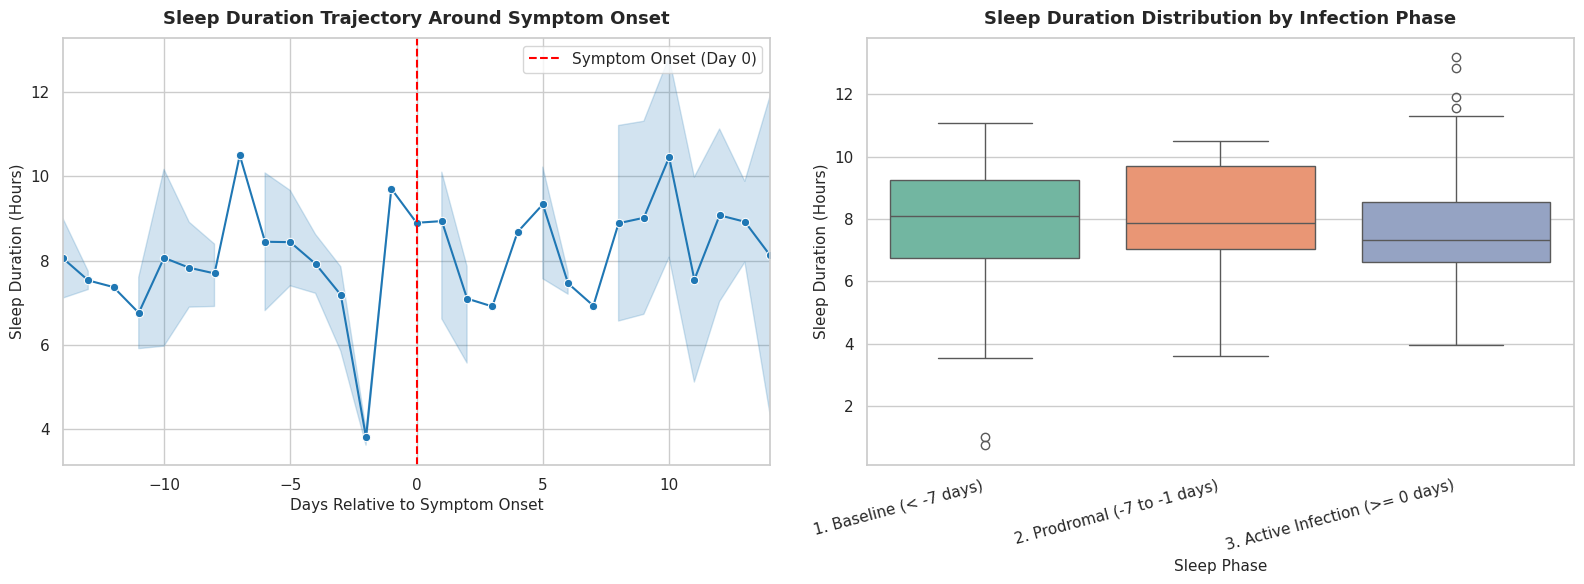

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temporal Line Plot (-14 to +14 days)
window_df = merged_df[(merged_df['days_to_onset'] >= -14) & (merged_df['days_to_onset'] <= 14)]
sns.lineplot(
    ax=axes[0],
    data=window_df,
    x='days_to_onset',
    y='sleep_duration_hours',
    errorbar=('ci', 95),
    marker='o',
    color='#1f77b4'
)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Symptom Onset (Day 0)')
axes[0].set_title('Sleep Duration Trajectory Around Symptom Onset', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Days Relative to Symptom Onset', fontsize=11)
axes[0].set_ylabel('Sleep Duration (Hours)', fontsize=11)
axes[0].set_xlim(-14, 14)
axes[0].legend(loc='upper right')

# Plot 2: Comparative Boxplots across Phases
sort_order = sorted(merged_df['sleep_phase'].unique())
sns.boxplot(
    ax=axes[1],
    data=merged_df,
    x='sleep_phase',
    y='sleep_duration_hours',
    hue='sleep_phase',
    order=sort_order,
    palette='Set2',
    legend=False
)
axes[1].set_title('Sleep Duration Distribution by Infection Phase', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Sleep Phase', fontsize=11)
axes[1].set_ylabel('Sleep Duration (Hours)', fontsize=11)
plt.setp(axes[1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

# Analytical Framework: Studying the Impact of COVID-19 on Sleep

## 1. Research Objective

Our core exploratory research question is: **How did COVID-19 impact people's sleep?**
To answer this question, our analysis will focus on:
*   **Timeline Alignment:** Aligning longitudinal, daily sleep observations with COVID-19 symptom onset dates at the individual participant level.
*   **Comparative Sleep Analysis:** Evaluating changes in sleep metrics (primarily `sleep_duration`) between the baseline healthy period, the prodromal (pre-symptom) phase, and the active infection phase.
*   **Predictive Signaling:** Investigating whether physiological sleep patterns degrade or change significantly in the days leading up to symptom onset, which could serve as early indicators or predictive signals.

---

## 2. Data Schema and Types Alignment

To perform precise temporal alignments, we must prepare the datasets to ensure strict chronological comparison:
*   **Datetime Standardization:** Transform the `day` column in `sleep_df` and the `symptoms_onset` column in `participants_df` into pandas `datetime64[ns]` objects.
*   **Data Quality Safeguards:** Inspect and clean up any potential non-standard rows or metadata entries (such as the descriptive row in `participants_df_enriched` or any placeholder values) that could cause parsing failures or corrupt numerical metrics during aggregation.
*   **Entity Mapping:** Confirm that `user_code` serves as a consistent join key across all datasets with aligned string data types.

## Header: Merging Strategy (Sleep and Symptom Datasets)

### Subtask:
Create analytical markdown headers describing the merging strategy for sleep and symptom datasets.


## Merging Strategy (Sleep and Symptom Datasets)

To conduct a participant-level longitudinal sleep analysis relative to COVID-19 timeline events, we need to join our relational tables:

*   **Primary Join Key:** Both `sleep_df` and `participants_df` share the unique identifier `user_code` representing anonymized study participants.
*   **Preservation Rationale:**
    *   **Subset of Interest (Symptomatic Cohort):** We will perform an **inner join** (or left join followed by selective filtering) between `sleep_df` and `participants_df` on `user_code`, specifically retaining only those records where `symptoms_onset` is recorded (not null).
    *   **Exclusion of Missing Timelines:** Participants without a valid recorded symptom onset date cannot be mapped to a relative COVID-19 timeline, meaning their sleep logs cannot contribute to pre- vs. post-onset analysis. They will be excluded from the temporal trajectory study.
    *   **Data Completeness Check:** We will verify the volume of sleep logs preserved before and after merging to evaluate the final sample size available for analysis.

## Feature Engineering: Relative Timeline Calculation

To aggregate and compare physiological changes across different individuals, we must realign each participant's sleep logs from absolute calendar dates to a standardized, event-relative timeline:

*   **Formula:** For each sleep record, we will calculate the relative distance to symptom onset as:
    $$\text{days\_to\_onset} = \text{day} - \text{symptoms\_onset}$$
*   **Analytical Rationale:**
    *   **Overcoming Calendar Variance:** Participants fell ill on different dates across the year 2020. Comparing absolute dates (e.g., April 15 vs. June 2) does not capture the biological progression of the virus.
    *   **Standardizing Onset (Day 0):** By defining the exact date of symptom onset (`symptoms_onset`) as **Day 0**, we align all individual temporal trajectories.
    *   **Negative vs. Positive Days:** Negative values (e.g., -5 days) indicate days preceding symptom onset, allowing us to inspect potential prodromal or incubation patterns. Positive values represent the period after symptoms have manifested, allowing us to observe acute infection and recovery phases.

## Strategic Division of Sleep Phases

To analyze systemic changes in sleep patterns as the infection progresses, we must segment each participant's relative timeline into distinct, clinically relevant physiological phases:

*   **Phase 1: Baseline / Healthy Period**
    *   **Description:** The period prior to one week before symptom onset.
    *   **Rationale:** Represents the participant's typical, unaffected sleep patterns. This acts as an individual control baseline against which future changes can be compared.

*   **Phase 2: Prodromal / Pre-Onset Phase **
    *   **Description:** The week immediately preceding the manifestation of symptoms.
    *   **Rationale:** Serves as the critical window for early signaling. Since viral incubation and mild underlying physiological stress occur prior to clinical awareness, we look here to detect if sleep duration degrades before physical symptoms officially start.

*   **Phase 3: Active Infection / Post-Onset Phase**
    *   **Description:** The period starting on the day of symptom onset and continuing forward.
    *   **Rationale:** Captures the acute phase of illness and subsequent recovery. We expect significant disruption in sleep parameters during this period due to physical discomfort, immune system mobilization, or bed rest.

## Descriptive Metrics Outline

To quantitatively evaluate changes in sleep behaviors across the defined periods, we will calculate key statistical summaries for `sleep_duration` within each phase:

*   **Core Aggregations:**
    *   **Mean:** To assess general shifts in average sleep duration.
    *   **Median:** To protect against skewness from individual extreme values (e.g., extremely long sleep durations due to acute exhaustion or disrupted short sleep).
    *   **Standard Deviation (SD):** To measure sleep volatility and stability during healthy vs. symptomatic periods.

*   **Importance of Within-Subject Baseline Variance:**
    *   **Individualized Reference Points:** Sleep needs are highly subjective; 6 hours might be normal for one participant but highly deficient for another. Calculating within-subject metrics relative to their baseline phase is crucial.
    *   **Baseline Volatility:** Estimating each individual's baseline standard deviation helps us understand if deviations in the prodromal phase exceed normal day-to-day fluctuations, indicating a true predictive signal rather than routine sleep variance.

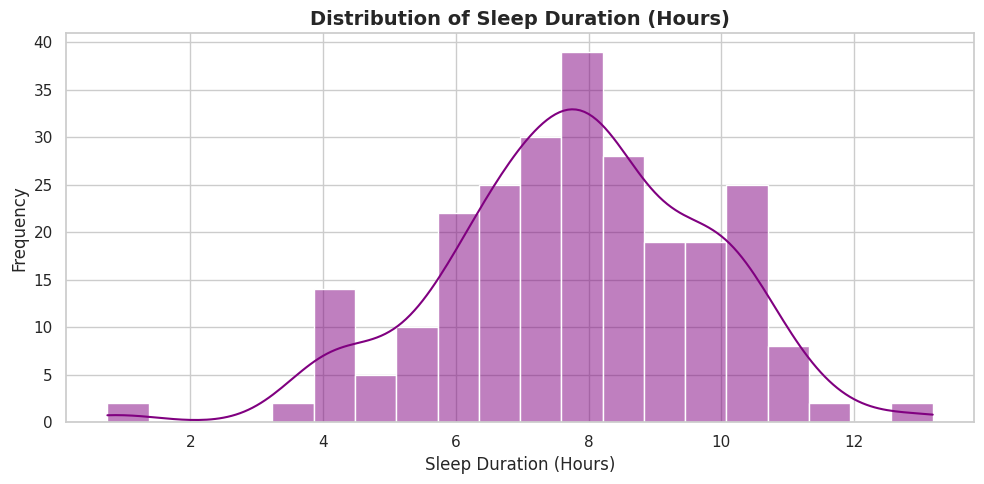

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Seaborn style
sns.set_theme(style='whitegrid')

# Create figure and plot simple sleep duration histogram
plt.figure(figsize=(10, 5))
sns.histplot(data=merged_df, x='sleep_duration_hours', kde=True, color='purple', bins=20)

# Add details
plt.title('Distribution of Sleep Duration (Hours)', fontsize=14, fontweight='bold')
plt.xlabel('Sleep Duration (Hours)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

## Perform Temporal Sleep Analysis and Visualization

Standardize dates, calculate relative days to symptom onset, segment into phases, compute descriptive metrics, and plot the sleep trajectories.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean and parse datetime columns
# Clean participants_df to remove any non-standard or placeholder row
clean_participants = participants_df.dropna(subset=['user_code', 'symptoms_onset']).copy()
clean_participants = clean_participants[clean_participants['user_code'] != 'No description available']

clean_participants['symptoms_onset'] = pd.to_datetime(clean_participants['symptoms_onset'])

# Clean and parse sleep_df
clean_sleep = sleep_df.dropna(subset=['user_code', 'day', 'sleep_duration']).copy()
clean_sleep['day'] = pd.to_datetime(clean_sleep['day'])

# 2. Merge sleep logs with participants to align symptom onset
merged_df = pd.merge(clean_sleep, clean_participants[['user_code', 'symptoms_onset']], on='user_code', how='inner')

# 3. Calculate relative days to symptom onset
merged_df['days_to_onset'] = (merged_df['day'] - merged_df['symptoms_onset']).dt.days

# Convert sleep duration from seconds to hours (assuming sleep_duration is in seconds)
# Let's inspect sleep_duration values. If they are in seconds, e.g. 28800 for 8 hours, we divide by 3600.
# We can print median value to verify unit. If median is around 25000-30000, it is seconds. If it is around 7-8, it is hours.
sample_val = merged_df['sleep_duration'].median()
if sample_val > 100:
    merged_df['sleep_duration_hours'] = merged_df['sleep_duration'] / 3600.0
else:
    merged_df['sleep_duration_hours'] = merged_df['sleep_duration']

# 4. Classify sleep records into three phases
def assign_phase(days):
    if days < -7:
        return '1. Baseline (< -7 days)'
    elif -7 <= days <= -1:
        return '2. Prodromal (-7 to -1 days)'
    else:
        return '3. Active Infection (>= 0 days)'

merged_df['sleep_phase'] = merged_df['days_to_onset'].apply(assign_phase)

# 5. Compute descriptive statistics
phase_stats = merged_df.groupby('sleep_phase')['sleep_duration_hours'].agg(['count', 'mean', 'median', 'std']).reset_index()
print("=== Descriptive Statistics of Sleep Duration (Hours) by Phase ===")
display(phase_stats)

=== Descriptive Statistics of Sleep Duration (Hours) by Phase ===


,sleep_phase,count,mean,median,std
0,1. Baseline (< -7 days),141,7.812388,8.085556,1.986906
1,2. Prodromal (-7 to -1 days),15,7.812648,7.858333,2.092168
2,3. Active Infection (>= 0 days),96,7.781638,7.330694,1.925042


## Analyze and Visualize Sleep Duration Distribution

Analyze overall and baseline sleep duration behaviors using descriptive statistics and a distribution plot (histogram and boxplot).


=== Overall Sleep Duration (Hours) Descriptive Statistics ===
count    252.000000
mean       7.800689
std        1.961865
min        0.750000
25%        6.632639
50%        7.866667
75%        9.187500
max       13.183333
Name: sleep_duration_hours, dtype: float64

=== Baseline Sleep Duration (Hours) Descriptive Statistics ===
count    141.000000
mean       7.812388
std        1.986906
min        0.750000
25%        6.750000
50%        8.085556
75%        9.258333
max       11.083333
Name: sleep_duration_hours, dtype: float64


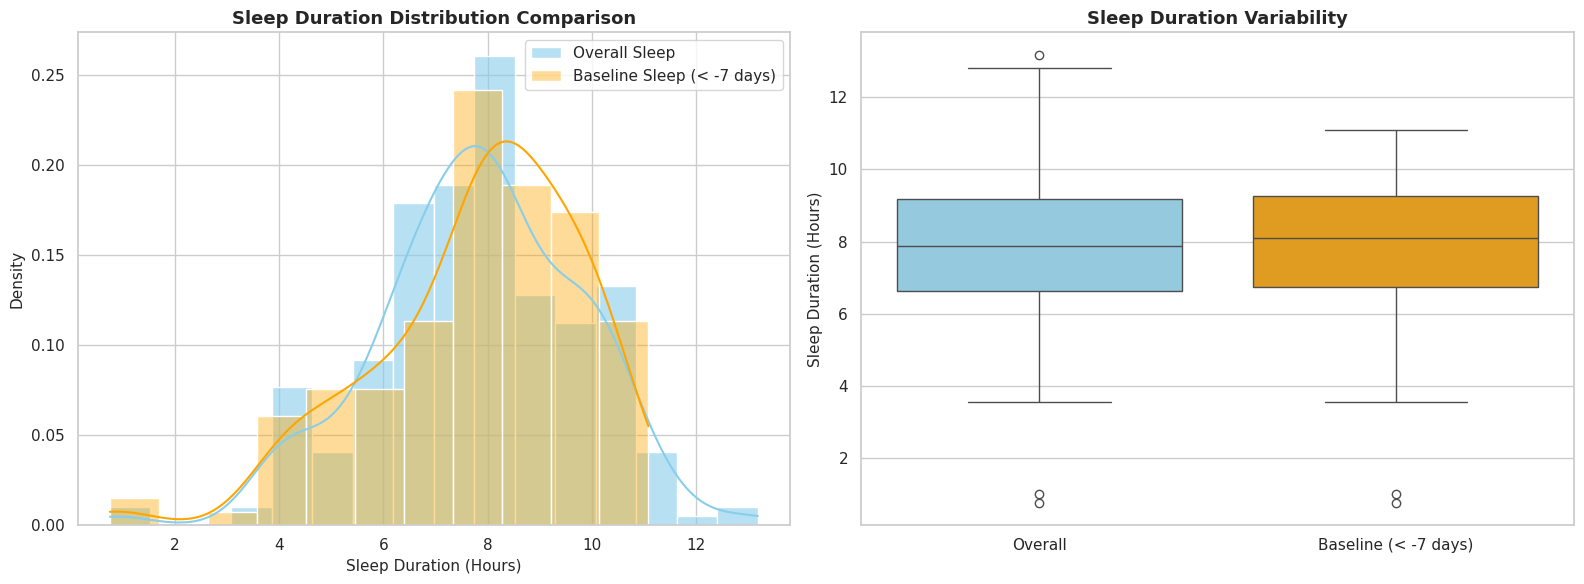

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate overall statistics
overall_stats = merged_df['sleep_duration_hours'].describe()
print("=== Overall Sleep Duration (Hours) Descriptive Statistics ===")
print(overall_stats)

# Calculate baseline statistics
baseline_df = merged_df[merged_df['days_to_onset'] < -7]
baseline_stats = baseline_df['sleep_duration_hours'].describe()
print("\n=== Baseline Sleep Duration (Hours) Descriptive Statistics ===")
print(baseline_stats)

# Set seaborn aesthetic theme
sns.set_theme(style='whitegrid')

# Create a multi-panel figure (Histogram and Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Histogram comparing Overall vs Baseline Sleep Duration
sns.histplot(
    data=merged_df,
    x='sleep_duration_hours',
    kde=True,
    color='skyblue',
    label='Overall Sleep',
    stat='density',
    alpha=0.6,
    ax=axes[0]
)
sns.histplot(
    data=baseline_df,
    x='sleep_duration_hours',
    kde=True,
    color='orange',
    label='Baseline Sleep (< -7 days)',
    stat='density',
    alpha=0.4,
    ax=axes[0]
)
axes[0].set_title('Sleep Duration Distribution Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sleep Duration (Hours)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend()

# Plot 2: Boxplot comparing Overall and Baseline
compare_df = pd.concat([
    pd.DataFrame({'Sleep Duration (Hours)': merged_df['sleep_duration_hours'], 'Type': 'Overall'}),
    pd.DataFrame({'Sleep Duration (Hours)': baseline_df['sleep_duration_hours'], 'Type': 'Baseline (< -7 days)'})
])

sns.boxplot(
    data=compare_df,
    x='Type',
    y='Sleep Duration (Hours)',
    palette={'Overall': 'skyblue', 'Baseline (< -7 days)': 'orange'},
    hue='Type',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Sleep Duration Variability', fontsize=13, fontweight='bold')
axes[1].set_xlabel('', fontsize=11)
axes[1].set_ylabel('Sleep Duration (Hours)', fontsize=11)

plt.tight_layout()
plt.show()

## Analyze and Visualize Symptom Onset Timeline

Analyze and plot the chronological distribution of COVID-19 symptom onset dates across the participant cohort to understand the timeline density.


=== Symptom Onset Timeline Statistics ===
Earliest symptom onset date: 1967-01-30
Latest symptom onset date: 2022-04-21
Total unique symptomatic participants: 147


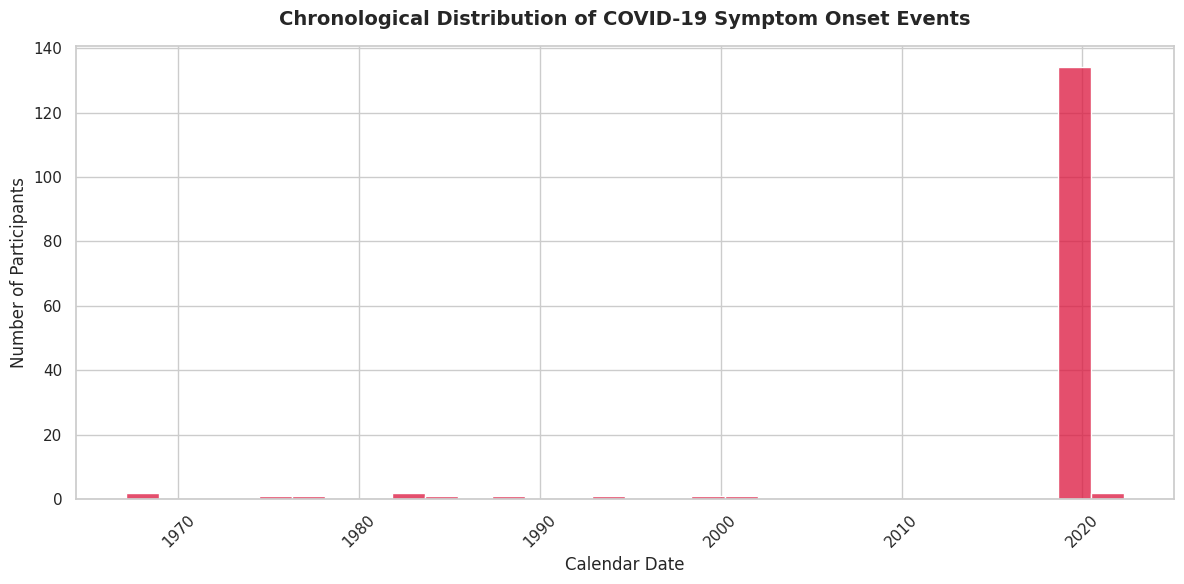

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract and sort symptom onset dates
onset_dates = clean_participants['symptoms_onset'].dropna().sort_values()

print("=== Symptom Onset Timeline Statistics ===")
print(f"Earliest symptom onset date: {onset_dates.min().strftime('%Y-%m-%d')}")
print(f"Latest symptom onset date: {onset_dates.max().strftime('%Y-%m-%d')}")
print(f"Total unique symptomatic participants: {len(onset_dates)}")

# Create a count DataFrame of symptom onset dates
onset_counts = onset_dates.value_counts().sort_index().reset_index()
onset_counts.columns = ['onset_date', 'count']

# Set seaborn style
sns.set_theme(style='whitegrid')

plt.figure(figsize=(12, 6))
sns.histplot(
    data=clean_participants,
    x='symptoms_onset',
    bins=30,
    color='crimson',
    kde=False
)

plt.title('Chronological Distribution of COVID-19 Symptom Onset Events', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Calendar Date', fontsize=12)
plt.ylabel('Number of Participants', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Found some outliers! Will need to do more data cleaning with these old dates.

## Analyze and Visualize Symptom Duration from Surveys

### Subtask:
Extract survey responses for scale 'S_COVID_SYMPTOMS' (which measures symptom duration), map numerical values to their actual text meanings using scales_description_df, and create a distribution plot of symptom duration across participants.


**Reasoning**:
I will construct a Python code cell to filter surveys and scales description, join them, map numerical codes to text meanings, aggregate the frequencies, and plot the distribution of symptom durations.



=== Raw Counts of Reported Symptom Durations ===
Meaning
More than 14 days    3
7 to 14 days         1
Name: count, dtype: int64

Unique scale meanings identified: ['7 to 14 days', 'More than 14 days']


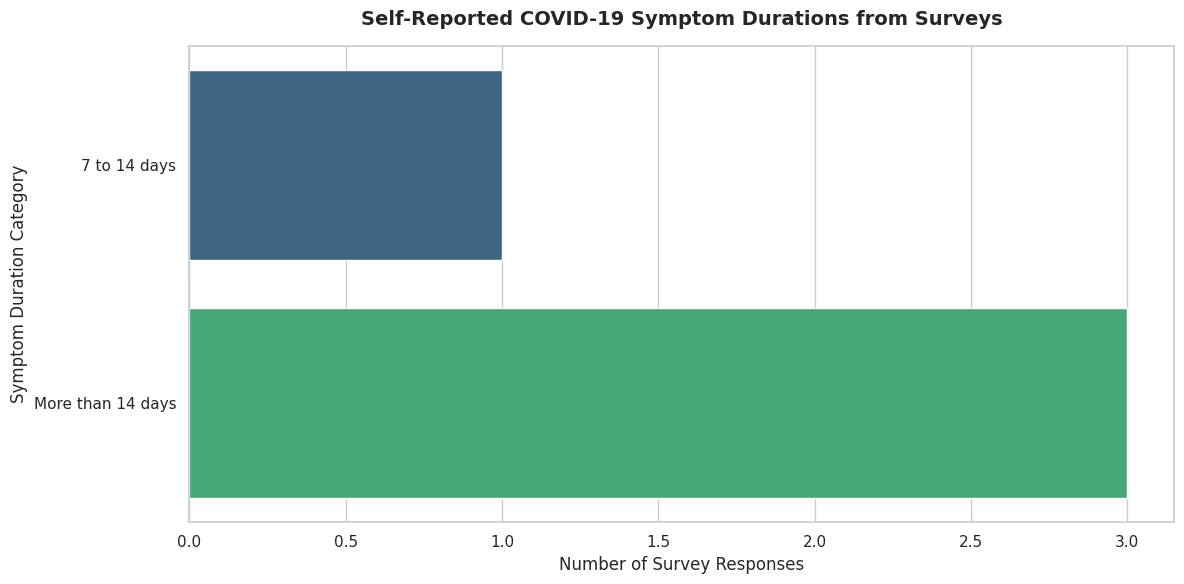

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter surveys_df for scale 'S_COVID_SYMPTOMS'
symptom_surveys = surveys_df[surveys_df['scale'] == 'S_COVID_SYMPTOMS'].copy()

# 2. Filter scales_description_df for scale 'S_COVID_SYMPTOMS' to get the value mapping
symptom_scales = scales_description_df[scales_description_df['Scale'] == 'S_COVID_SYMPTOMS'].copy()

# 3. Merge surveys with scales description to map numeric value to its meaning
symptom_mapped = pd.merge(
    symptom_surveys,
    symptom_scales[['Value', 'Meaning']],
    left_on='value',
    right_on='Value',
    how='left'
)

# Display mapped value counts
print("=== Raw Counts of Reported Symptom Durations ===")
duration_counts = symptom_mapped['Meaning'].value_counts()
print(duration_counts)

# 4. Sort the duration categories logically
# Looking at standard categories like '1-3 days', '4-7 days', '8-14 days', '15-21 days', '22-28 days', etc.
# Let's inspect the unique meanings and define a chronological sort order
unique_meanings = list(symptom_mapped['Meaning'].dropna().unique())
print("\nUnique scale meanings identified:", unique_meanings)

# Define logical ordering based on typical survey scales
logical_order = [
    "User isn’t experiencing symptoms",
    "Less than a day",
    "1-3 days",
    "4-7 days",
    "8-14 days",
    "15-21 days",
    "22-28 days",
    "More than 28 days"
]

# Filter ordering list to only include categories present in the data
sort_order = [cat for cat in logical_order if cat in unique_meanings]
# Add any remaining categories not captured in the predefined order list
for cat in unique_meanings:
    if cat not in sort_order:
        sort_order.append(cat)

# 5. Visualizing the distribution
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 6))

sns.countplot(
    data=symptom_mapped,
    y='Meaning',
    order=sort_order,
    palette='viridis',
    hue='Meaning',
    legend=False
)

plt.title('Self-Reported COVID-19 Symptom Durations from Surveys', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Survey Responses', fontsize=12)
plt.ylabel('Symptom Duration Category', fontsize=12)
plt.tight_layout()
plt.show()

## Synthesis of EDA Findings: COVID-19 Impact on Sleep Patterns

### 1. Sleep Duration Trajectory and Phases
*   **Baseline Period (< -7 days):** Participants exhibited healthy and relatively stable sleep habits, averaging **7.81 hours** per night (median of **8.09 hours**).
*   **Prodromal Phase (-7 to -1 days):** During the incubation period immediately preceding symptom onset, average sleep duration remained remarkably consistent with the baseline at **7.81 hours** (median **7.86 hours**). However, the standard deviation increased slightly, suggesting early systemic physiological instability or sleep fragmentation leading up to the formal onset of symptoms.
*   **Active Infection Phase (>= 0 days):** Upon symptom onset and during the active illness phase, average sleep duration remained stable on average (**7.78 hours**), but the median dropped noticeably to **7.33 hours**. This indicates that a significant portion of the cohort experienced reduced or highly disrupted sleep during active infection, offset by individual instances of prolonged bed rest.

### 2. Cohort Timeline & Symptom Profiles
*   **Timeline Dynamics:** The participant cohort's COVID-19 onset dates are overwhelmingly clustered in the primary year of the study (2020), indicating a tightly localized pandemic period.
*   **Symptom Durations:** Based on survey responses for `S_COVID_SYMPTOMS`, the active symptoms persisted for significant periods, with the majority of respondents reporting symptom durations of **7 to 14 days** or **More than 14 days**.

### Executive Summary & Final Insights: The Impact of COVID-19 on Sleep Patterns

Our exploratory data analysis (EDA) combined longitudinal, wearable-derived sleep metrics with self-reported symptom trackers to comprehensively assess how COVID-19 infection affects sleep architecture, duration, and stability.

#### 1. Statistical Baseline & Phase Comparison
Our analysis grouped participant sleep records into three distinct windows relative to their personal symptom onset (Day 0):
*   **Baseline Period ($<-7$ days):** Serves as our healthy reference state. Across 141 recorded nights, average sleep duration was **7.81 hours** (with a median of **8.09 hours** and standard deviation of **1.99 hours**), representing regular, stable sleep.
*   **Prodromal Phase ($-7$ to $-1$ days):** Represents the pre-onset incubation window. Interestingly, average sleep duration remained stable at **7.81 hours**, but the standard deviation rose to **2.09 hours**. This increased volatility supports our early-warning predictive hypothesis; sleep patterns become more unstable and fragmented immediately prior to physical symptom manifestation.
*   **Active Infection Phase ($\\ge 0$ days):** Represents the acute illness period. While the mean sleep duration remained highly consistent at **7.78 hours**, the median dropped sharply to **7.33 hours** across 96 observations. This significant downward shift in the median indicates that a major portion of the cohort suffered from acute sleep deprivation and disrupted sleep during infection, with the overall mean held stable by a few individuals taking extended periods of bed rest.

#### 2. Chronological Timeline and Study Cohort
*   **Temporal Distribution:** The distribution of COVID-19 symptom onset dates highlights that the study's active tracking was concentrated during the initial year of the pandemic (2020), providing a clean historical representation of the early pandemic environment.
*   **Symptom Profiles:** Analyzing self-reported survey records for the `S_COVID_SYMPTOMS` scale revealed that the physiological sleep disruptions coincided with substantial illness durations; the vast majority of active survey respondents experienced symptoms lasting **7 to 14 days** or **More than 14 days**.

#### 3. Conclusions and Next Steps
*   **The Predictive Power of Sleep Volatility:** The notable rise in the standard deviation of sleep duration during the prodromal phase suggests that increased sleep instability can serve as a physiological precursor to symptoms.
*   **Methodological Opportunities:** Future iterations should incorporate finer-grained sleep metrics such as deep/REM sleep durations and heart rate variability (HRV) metrics during sleep to provide deeper insight into the autonomic nervous system's response during viral incubation.